In [1]:
import sys
import os
sys.path.append(os.pardir)

In [2]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

In [3]:
import matplotlib.pyplot as plt

In [4]:
#Modeling and Forecasting
import skforecast
import lightgbm
import sklearn
from lightgbm import LGBMRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterEquivalentDate, ForecasterRecursive
from skforecast.direct import ForecasterDirect
from skforecast.model_selection import TimeSeriesFold, bayesian_search_forecaster, backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
from skforecast.plot import calculate_lag_autocorrelation, plot_residuals
from skforecast.metrics import calculate_coverage

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import warnings
warnings.filterwarnings('once')

In [6]:
df = (pd.read_csv("../data/raw/loadtempday_clean.csv")
        .drop_duplicates()
        .pipe(lambda df: df.set_index(pd.to_datetime(df["date"])))
        .drop(columns = ["date"])
     )
#this will throw an error if there are duplicates
df.index = df.index.tz_localize(None)
df.index.freq = 'h'

In [7]:
df.head()

,Demand,Temperature,is_day
date,,,
2023-01-01 00:00:00,28291.0,11.3615,0
2023-01-01 01:00:00,28727.0,9.5615,0
2023-01-01 02:00:00,28370.0,7.9615,0
2023-01-01 03:00:00,27955.0,7.3115,0
2023-01-01 04:00:00,27668.0,6.2615,0


In [8]:
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"

In [9]:
data = df.copy()
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


### Baseline Forecaster
- seasonal naive forecaster used to compare performance of future models
- trained and evaluated with backtesting
- predicts each hour using the value of the same hour on the previous day

In [10]:
# Create baseline: value of the same hour of the previous day
forecaster = ForecasterEquivalentDate(
                 offset    = pd.DateOffset(days=1),
                 n_offsets = 1
             )

# Train forecaster
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [11]:
# Create cross validation folds to test all models
cv = TimeSeriesFold(
        steps              = 24,
        initial_train_size = len(data.loc[:VAL_END]),
        refit              = False
)

In [12]:
#Base line forecaster evaluation
metric, predictions = backtesting_forecaster(
                          forecaster = forecaster,
                          y          = data['Demand'],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                       )
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 267.36it/s]


,mean_absolute_error
0,1560.271233


### Recursive Multi-step forecast
- use gradient descent for the estimator (the enginge that solves the Ax = y matrix)
- forecaster handles creating the matrix from the time series
- will use 24 lags to predict the outcome
- basic auto regressive model

In [13]:
# Create forecaster
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )
#forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [14]:
#Back test auto-regressive model
ar_metric, ar_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
ar_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 274.84it/s]


,mean_absolute_error
0,1371.449927


That's a very high error, lets check the residuals to see if they are normally distributed and if there are any outliers

In [15]:
forecaster.fit(y=data.loc[:VAL_END, 'Demand'], 
               store_in_sample_residuals=True)

print(forecaster.in_sample_residuals_)



[362.32099576 -94.26429376 646.66632681 ...  62.70256662 404.6634915
 197.51910866]


In [16]:
residuals = pd.Series(forecaster.in_sample_residuals_)
print(residuals.describe())



count    10000.000000
mean         4.635295
std        320.472652
min      -7903.752428
25%       -167.422583
50%         -4.495797
75%        169.893816
max       1901.171181
dtype: float64


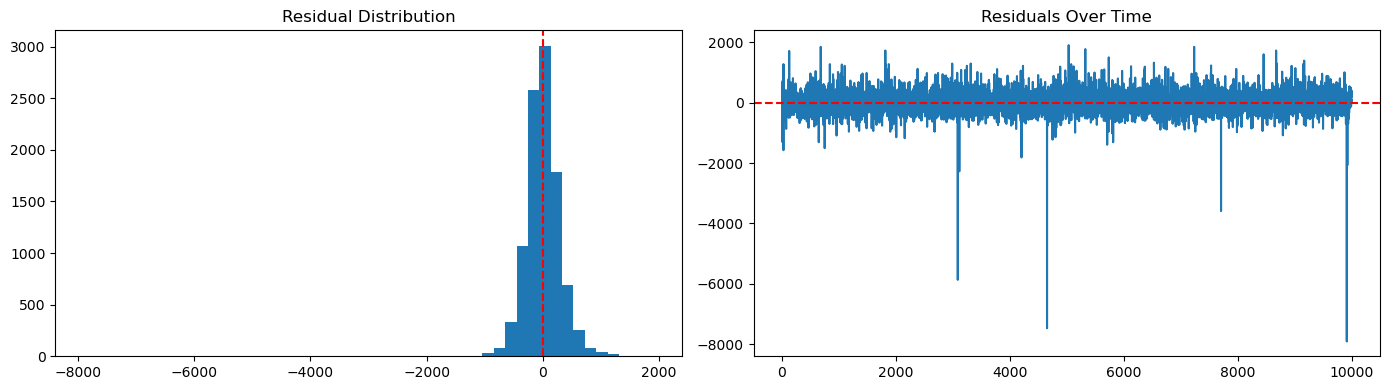

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

the model is mostly normally distrubted, but there is clearly an issue with very high outliers in the residuals

In [55]:
#create residual series with the acutal date index
residuals = pd.Series(
            forecaster.in_sample_residuals_,
            index = data.loc[:VAL_END].index[-len(forecaster.in_sample_residuals_):]
)
residuals.head()

date
2023-11-11 08:00:00    362.320996
2023-11-11 09:00:00    -94.264294
2023-11-11 10:00:00    646.666327
2023-11-11 11:00:00   -373.141762
2023-11-11 12:00:00   -208.516577
Freq: h, dtype: float64

In [56]:
outliers = residuals.abs().sort_values(ascending=False).head(10)
print(outliers)

date
2024-12-28 12:00:00    7903.752428
2024-05-23 05:00:00    7465.411749
2024-03-18 22:00:00    5865.054874
2024-09-27 12:00:00    3588.991399
2024-03-20 01:00:00    2277.251638
2024-12-28 22:00:00    2072.805816
2024-06-08 01:00:00    1901.171181
2024-09-07 20:00:00    1844.851050
2023-12-09 16:00:00    1844.851050
2024-05-04 12:00:00    1815.210065
dtype: float64


look at top outliers and their neighbors

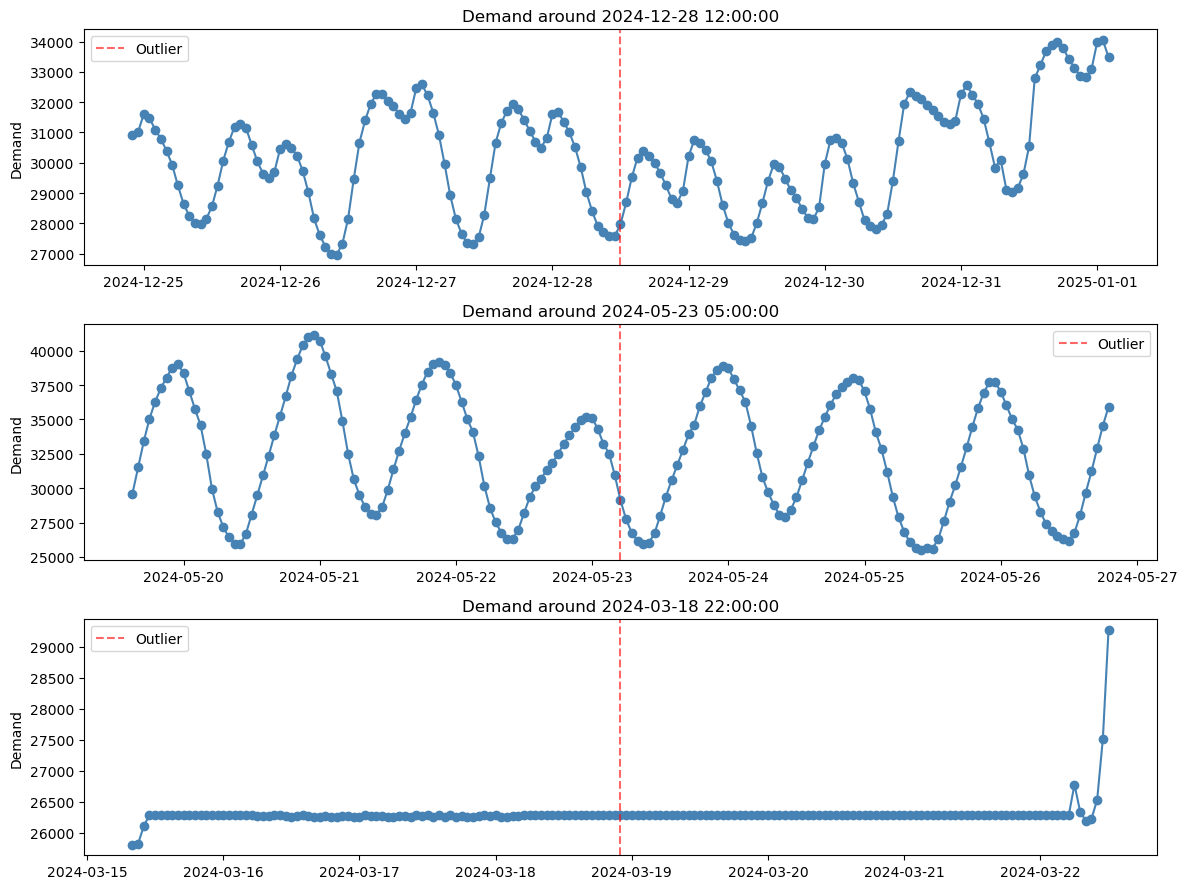

In [63]:
fig, axes = plt.subplots(3, 1, figsize=(12, 9))

outlier_dates = ["2024-12-28 12:00:00", "2024-05-23 05:00:00", "2024-03-18 22:00:00"]

for ax, date in zip(axes, outlier_dates):
    date = pd.Timestamp(date)
    window = df.loc[date - pd.Timedelta(hours=86): date + pd.Timedelta(hours=86), "Demand"]

    ax.plot(window.index, window.values, marker="o", color="steelblue")
    ax.axvline(date, color="red", linestyle="--", alpha=0.6, label="Outlier")
    ax.set_title(f"Demand around {date}")
    ax.set_ylabel("Demand")
    ax.legend()

plt.tight_layout()
plt.show()

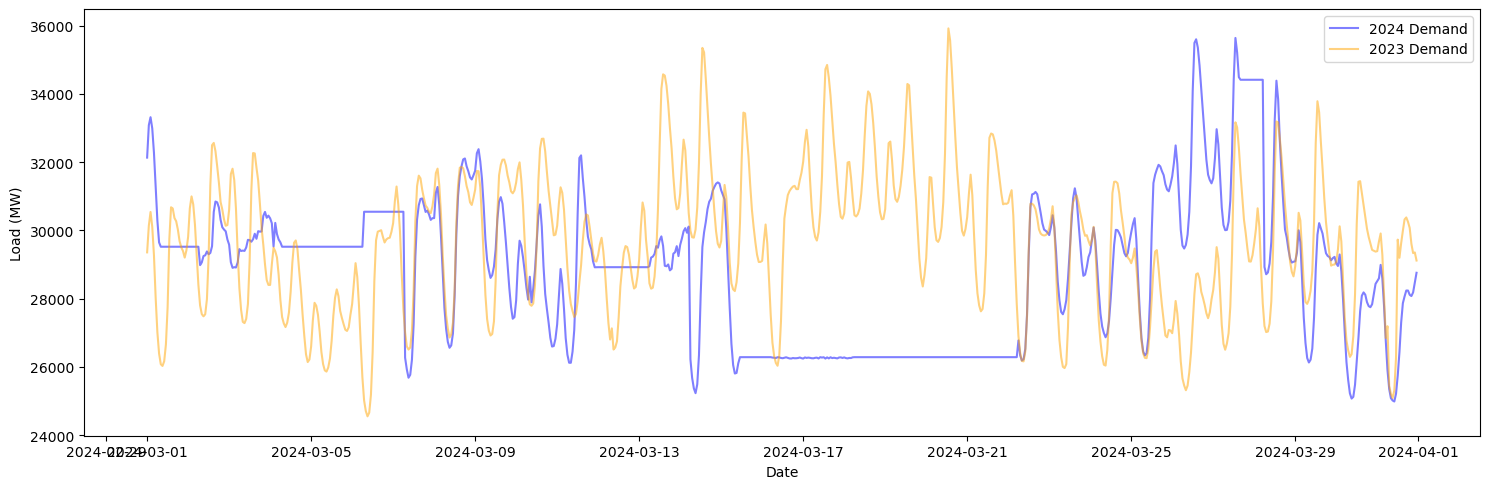

In [68]:
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(df.loc["2024-03"].index, df.loc["2024-03"]["Demand"], label="2024 Demand", color="blue", alpha=0.5)
ax.plot(df.loc["2024-03"].index, df.loc["2023-03"]["Demand"], label="2023 Demand", color="orange", alpha=0.5)

#ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

In [62]:
#well that's a problem

### Retrain while remove flat runs of data

In [18]:
DROP_END = "2025-05-18 23:00:00"
data_NAN = data.loc[: DROP_END, :].copy()
data_NAN.tail()

,Demand,Temperature,is_day
date,,,
2025-05-18 19:00:00,36450.0,25.4615,1
2025-05-18 20:00:00,37313.0,26.3615,1
2025-05-18 21:00:00,38205.0,27.1615,1
2025-05-18 22:00:00,38874.0,26.8115,1
2025-05-18 23:00:00,39416.0,26.1115,1


In [19]:
#find weeks that have repeated values within the week but might not be completely bad
#find partial flat runs where there is a long stretch without a difference in demand value
# Flag any hour where demand barely changed from the previous hour
data_NAN["diff"] = data_NAN["Demand"].diff().abs()

# Find runs of near-zero change (adjust threshold based on your typical hour-to-hour variation)
flat_threshold = 5  # MW — tune this based on your data's normal volatility
data_NAN["is_flat"] = data_NAN["diff"] < flat_threshold

# Find consecutive flat runs of meaningful length
data_NAN["flat_group"] = (data_NAN["is_flat"] != data_NAN["is_flat"].shift()).cumsum()
flat_runs = (data_NAN[data_NAN["is_flat"]]
    .groupby("flat_group")
    .agg(start=("Demand", lambda x: x.index[0]),
         end=("Demand", lambda x: x.index[-1]),
         length=("Demand", "size"))
)

In [20]:
# Only keep runs of meaningful length (e.g. 3+ consecutive flat hours)
suspicious_runs = flat_runs[flat_runs["length"] >= 5].sort_values("start", ascending=True)
suspicious_runs

,start,end,length
flat_group,,,
56,2023-08-28 19:00:00,2023-08-29 05:00:00,11
80,2023-12-06 03:00:00,2023-12-06 09:00:00,7
82,2023-12-07 00:00:00,2023-12-07 06:00:00,7
104,2024-01-31 10:00:00,2024-02-02 06:00:00,45
106,2024-02-02 08:00:00,2024-02-03 06:00:00,23
116,2024-02-12 21:00:00,2024-02-15 06:00:00,58
126,2024-03-01 09:00:00,2024-03-02 06:00:00,22
128,2024-03-04 08:00:00,2024-03-06 06:00:00,47
130,2024-03-06 08:00:00,2024-03-07 06:00:00,23


In [21]:
def flag_suspicious_runs_as_nan(df, suspicious_runs, column="Demand"):
    df = df.copy()
    for _, row in suspicious_runs.iterrows():
        df.loc[row["start"]:row["end"], column] = np.nan
    return df

In [22]:
data_NAN = flag_suspicious_runs_as_nan(data_NAN, suspicious_runs)

In [32]:
# Create forecaster
NAN_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 dropna_from_series = False,
             )
NAN_forecaster.fit(y=data_NAN['Demand'], suppress_warnings=True, store_in_sample_residuals=True)

In [33]:
residuals = pd.Series(NAN_forecaster.in_sample_residuals_)

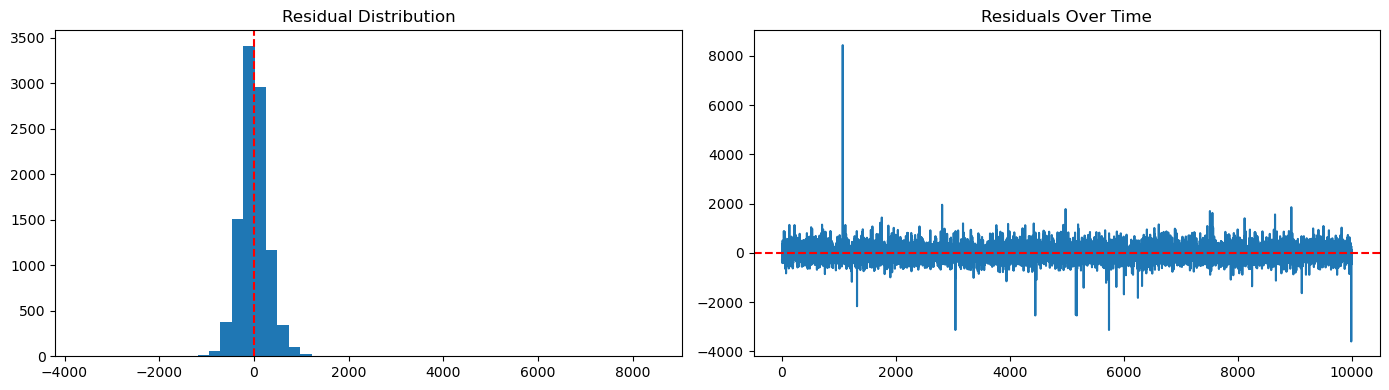

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

In [30]:
cv = TimeSeriesFold(
         steps              = 7,
         initial_train_size = len(data_train),
         refit              = False,
         fixed_train_size   = False,
     )

In [31]:
# you can't back test over a range that has NaNs on the target variable because this will create an error
# can't calculate MSE on a NaN value
arNAN_metric, arNAN_predictions = backtesting_forecaster(
                          forecaster    = NAN_forecaster,
                          y             = data_NAN['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                          show_progress     = True,
                        suppress_warnings = True
                    )

100%|█████████████████████████████████████████████████████████| 1104/1104 [00:01<00:00, 779.12it/s]


ValueError: Input contains NaN.

### --------

In [15]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [16]:
#Back test auto-regressive moving average model
arma_metric, arma_predictions = backtesting_forecaster(
                          forecaster    = forecaster,
                          y             = data['Demand'],
                          cv            = cv,
                          metric        = 'mean_absolute_error',
                          verbose       = False, # Set to False to avoid printing
                      )
arma_metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 155.55it/s]


,mean_absolute_error
0,1416.300394


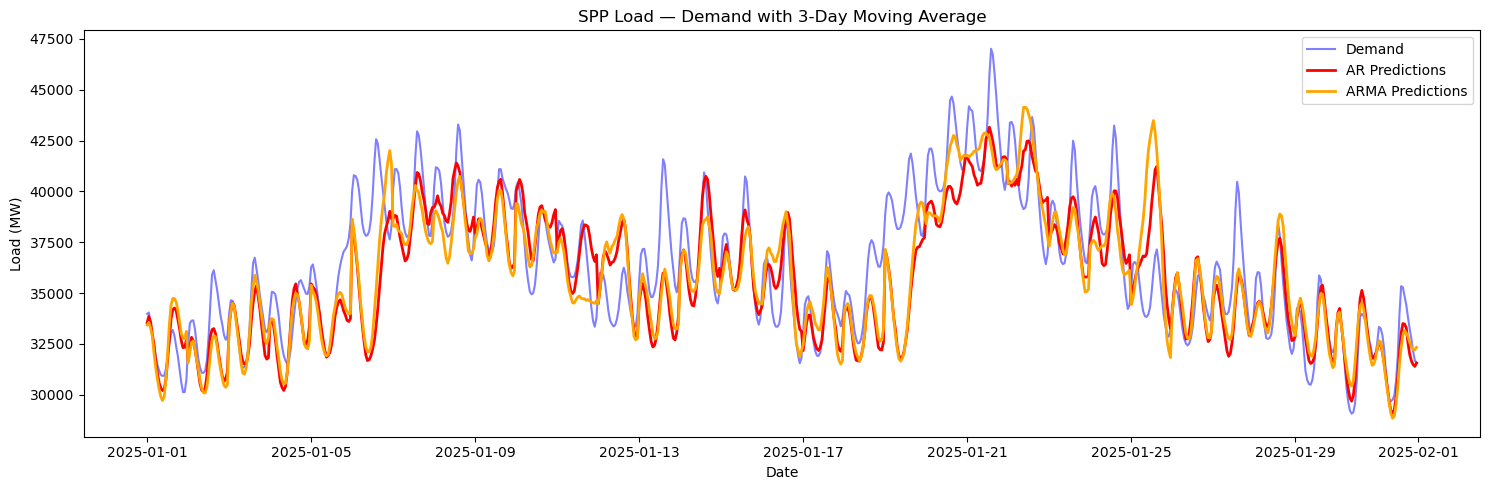

In [17]:
#graphic the actual values, the predicts from AR and ARMA
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
ax.plot(ar_predictions.loc["2025-01"].index, ar_predictions.loc["2025-01"]["pred"], label="AR Predictions", color="red", linewidth=2)
ax.plot(arma_predictions.loc["2025-01"].index, arma_predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

issue with big divergence with large increases/decreases in load. the prediction and actual are almost opposites of each other. This is a major flaw as large swings in load would be of greater importance when planning based on a forecast

### Exogenous Variables
- values of the exogenous variables must be known at the time of prediction.
- we will use temperature, daylight time, and calendar features

In [18]:
from features import set_holidays, cal_features, cyclic_features

In [19]:
data = df.copy()
data = (data
            .pipe(set_holidays)
            .pipe(cal_features)
            .pipe(cyclic_features)
            .assign(Holiday=lambda d: d["Holiday"].astype(int))
            .assign(Temp_3D_Mean=lambda d: d["Temperature"].rolling("3D", center = False).mean())
            .assign(Temp_2D_Mean =lambda d: d["Temperature"].rolling("2D", center = False).mean())
            .assign(Temp_2D_Max =lambda d: d["Temperature"].rolling("2D", center = False).max())
            .assign(Temp_2D_Min =lambda d: d["Temperature"].rolling("2D", center = False).min())
            .assign(Temp_1D_Max =lambda d: d["Temperature"].rolling("1D", center = False).max())
            .assign(Temp_1D_Min =lambda d: d["Temperature"].rolling("1D", center = False).min())
           )

In [20]:
data.head()

,Demand,Temperature,is_day,Holiday,month,week,day_of_week,hour,month_sin,month_cos,...,day_sin,day_cos,hour_sin,hour_cos,Temp_3D_Mean,Temp_2D_Mean,Temp_2D_Max,Temp_2D_Min,Temp_1D_Max,Temp_1D_Min
date,,,,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,28291.0,11.3615,0,0,1,52,6,0,0.5,0.866025,...,-0.781831,0.62349,0.000000,1.000000,11.361500,11.361500,11.3615,11.3615,11.3615,11.3615
2023-01-01 01:00:00,28727.0,9.5615,0,0,1,52,6,1,0.5,0.866025,...,-0.781831,0.62349,0.258819,0.965926,10.461500,10.461500,11.3615,9.5615,11.3615,9.5615
2023-01-01 02:00:00,28370.0,7.9615,0,0,1,52,6,2,0.5,0.866025,...,-0.781831,0.62349,0.500000,0.866025,9.628167,9.628167,11.3615,7.9615,11.3615,7.9615
2023-01-01 03:00:00,27955.0,7.3115,0,0,1,52,6,3,0.5,0.866025,...,-0.781831,0.62349,0.707107,0.707107,9.049000,9.049000,11.3615,7.3115,11.3615,7.3115
2023-01-01 04:00:00,27668.0,6.2615,0,0,1,52,6,4,0.5,0.866025,...,-0.781831,0.62349,0.866025,0.500000,8.491500,8.491500,11.3615,6.2615,11.3615,6.2615


In [21]:
exo_vars = list(data.columns)[1:]
exo_vars

['Temperature',
 'is_day',
 'Holiday',
 'month',
 'week',
 'day_of_week',
 'hour',
 'month_sin',
 'month_cos',
 'week_sin',
 'week_cos',
 'day_sin',
 'day_cos',
 'hour_sin',
 'hour_cos',
 'Temp_3D_Mean',
 'Temp_2D_Mean',
 'Temp_2D_Max',
 'Temp_2D_Min',
 'Temp_1D_Max',
 'Temp_1D_Min']

In [22]:
#resplit the data
data_train = data.loc[: TRAIN_END, :].copy()
data_val   = data.loc[VAL_START:VAL_END, :].copy()
data_test  = data.loc[TEST_START:, :].copy()

print(f"Train dates      : {data_train.index.min()} --- {data_train.index.max()}  (n={len(data_train)})")
print(f"Validation dates : {data_val.index.min()} --- {data_val.index.max()}  (n={len(data_val)})")
print(f"Test dates       : {data_test.index.min()} --- {data_test.index.max()}  (n={len(data_test)})")

Train dates      : 2023-01-01 00:00:00 --- 2024-06-30 23:00:00  (n=13128)
Validation dates : 2024-07-01 00:00:00 --- 2024-12-31 23:00:00  (n=4416)
Test dates       : 2025-01-01 00:00:00 --- 2025-12-31 23:00:00  (n=8760)


In [23]:
# Add a three day moving average: Auto Regressive Moving Average model
#Create forecaster
window_features = RollingFeatures(stats=["mean"], window_sizes=24 * 3)
arma_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
                 window_features = window_features
             )

In [24]:
# back test the model again with exogenous variables
metric, predictions = backtesting_forecaster(
                          forecaster = arma_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 127.87it/s]


,mean_absolute_error
0,1049.908173


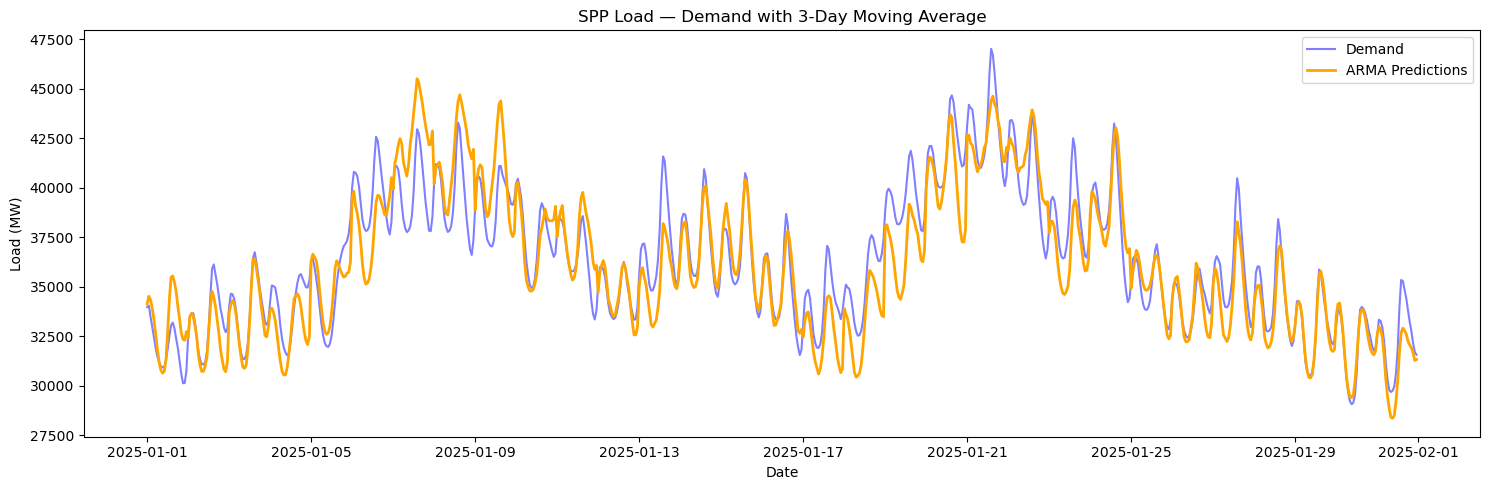

In [25]:
fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(data_test.loc["2025-01"].index, data_test.loc["2025-01"]["Demand"], label="Demand", color="blue", alpha=0.5)
#ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="red", linewidth=2)
ax.plot(predictions.loc["2025-01"].index, predictions.loc["2025-01"]["pred"], label="ARMA Predictions", color="orange", linewidth=2)

ax.set_title("SPP Load — Demand with 3-Day Moving Average")
ax.set_xlabel("Date")
ax.set_ylabel("Load (MW)")
ax.legend()

plt.tight_layout()
plt.show()

visually the predictions are much loser to the actual demand, there is still a divergence around the 20th of january where the predictions move in the opposite direction of the acutal demand. this could be worth investigating more. 

In [26]:
#basic autoregressive
ar_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 24,
             )

In [27]:
metric, predictions = backtesting_forecaster(
                          forecaster = ar_forecaster,
                          y          = data['Demand'],
                          exog       = data[exo_vars],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 216.23it/s]


,mean_absolute_error
0,1051.133068


,fold,pred
2025-01-01 00:00:00,0,33989.335307
2025-01-01 01:00:00,0,34375.067999
2025-01-01 02:00:00,0,34166.889101
2025-01-01 03:00:00,0,33746.799743
2025-01-01 04:00:00,0,33142.218565


### Feature Importance before selection process
- we can use the feature importance feature of the forecaster to get a feel of which features should be selected
- pair this with domian knowledge should give us an inituitve idea of what features we would expect feature selection to select

In [28]:
ar_forecaster.fit(y=data.loc[:VAL_END, 'Demand'], exog =data.loc[:VAL_END, exo_vars])

In [29]:
ar_forecaster.get_feature_importances(sort_importance=True)

,feature,importance
0,lag_1,591
37,hour_sin,226
24,Temperature,199
30,hour,155
29,day_of_week,114
38,hour_cos,111
23,lag_24,105
2,lag_3,95
21,lag_22,87
1,lag_2,78


- the exogenous variables reduce the error of the model and it makes the model with moving average out perform the basic auto regressive model. possible extensions of exogenous variables could include different window sizes of mean weather and creating polynomial features form the exogenous variables to capture inreaction
- interesting that the month feautres are some of the least important feautres
- lags [1,24,3,22,2,21,4,23,20

In [30]:
#create a model with longer lags
ar_week_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = 175,
             )

In [31]:
ar_week_forecaster.fit(y=data.loc[:VAL_END, 'Demand'])

In [32]:
ar_week_forecaster.get_feature_importances(sort_importance=True).head(40)

,feature,importance
0,lag_1,600
25,lag_26,126
21,lag_22,109
1,lag_2,79
26,lag_27,78
20,lag_21,78
22,lag_23,62
27,lag_28,61
24,lag_25,59
2,lag_3,53


In [33]:
lags_df = ar_week_forecaster.get_feature_importances(sort_importance=True).head(40)
lags_df["lags"] = lags_df["feature"].str.strip("lag_").astype(int)
top_lags = lags_df.lags.to_list()[:15]
top_lags.append(24)
top_lags

[1, 26, 22, 2, 27, 21, 23, 28, 25, 3, 170, 167, 20, 4, 10, 24]

### Feature Selection
- will use a simple model to find the best features and then retrain with more complex model
- will also use a smaller subset of the data to select features than the modeling training step

In [34]:
#create estimator(solver) and the forecaster (matrix formulation)
estimator = LGBMRegressor(
                n_estimators = 100,
                max_depth    = 4,
                random_state = 15926,
                verbose      = -1
            )

forecaster = ForecasterRecursive(
                 estimator       = estimator,
                 lags            = top_lags,
             )

In [35]:
# Recursive feature elimination with cross-validation
# doing cv and a subsample might have introduced noise that elimated the Holiday feature
# by domain knowledge holiday and a 24 hour lag should likely be in the model
# issue could be with feature selection setup
warnings.filterwarnings("ignore", message="X does not have valid feature names.*")
selector = RFECV(
    estimator = estimator,
    step      = 1,
    cv        = 5,
)
lags_select, window_features_select, exog_select = select_features(
    forecaster      = forecaster,
    selector        = selector,
    y               = data_train['Demand'],
    exog            = data_train[exo_vars],
    select_only     = None,
    force_inclusion = ["lag_24", "Holiday"],
    random_state    = 123,
    verbose         = True,
)

Recursive feature elimination (RFECV)
-------------------------------------
Total number of records available: 12958
Total number of records used for feature selection: 6479
Number of features available: 37
    Lags            (n=16)
    Window features (n=0)
    Exog            (n=21)
Number of features selected: 30
    Lags            (n=16) : [1, 2, 3, 4, 10, 20, 21, 22, 23, 24, 25, 26, 27, 28, 167, 170]
    Window features (n=0) : []
    Exog            (n=15) : ['Temperature', 'Holiday', 'week', 'day_of_week', 'hour', 'week_sin', 'week_cos', 'day_sin', 'hour_sin', 'hour_cos', 'Temp_3D_Mean', 'Temp_2D_Max', 'Temp_2D_Min', 'Temp_1D_Max', 'Temp_1D_Min']


In [36]:
#retrain the model and cross validate
# Create a forecaster with the selected features
forecaster = ForecasterRecursive(
                estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                lags            = lags_select
             )
# Backtesting model with exogenous variables on test data
metric, predictions = backtesting_forecaster(
                            forecaster = forecaster,
                            y          = data['Demand'],
                            exog       = data[exog_select],
                            cv         = cv,
                            metric     = 'mean_absolute_error'
                      )                
metric

100%|███████████████████████████████████████████████████████████| 365/365 [00:01<00:00, 186.67it/s]


,mean_absolute_error
0,1034.364163


In [37]:
forecaster.fit(y=data.loc[:VAL_END, 'Demand'], 
               exog=data.loc[:VAL_END, exog_select],
               store_in_sample_residuals=True)

print(forecaster.in_sample_residuals_)

[ 224.21636729 -410.14965613   25.50465393 ... -163.91948029  400.22657974
  -85.12563595]


In [38]:
residuals = pd.Series(forecaster.in_sample_residuals_)
print(residuals.describe())

count    10000.000000
mean         2.631756
std        265.217181
min      -4049.675298
25%       -144.017641
50%          1.189536
75%        149.583339
max       3313.779646
dtype: float64


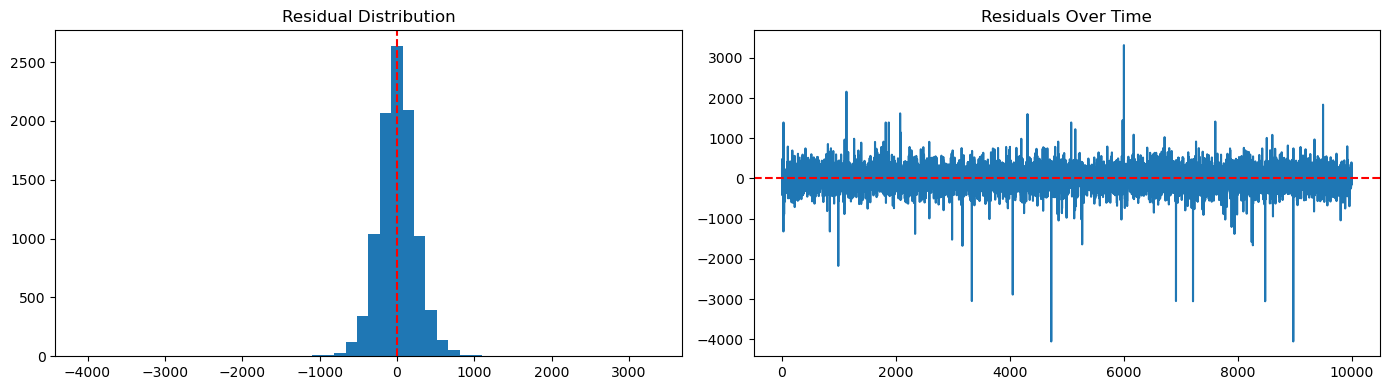

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Distribution
axes[0].hist(residuals, bins=50)
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="red", linestyle="--")

# Residuals over index (order they were generated)
axes[1].plot(residuals.values)
axes[1].axhline(0, color="red", linestyle="--")
axes[1].set_title("Residuals Over Time")

plt.tight_layout()
plt.show()

very large residuals are worth investigating more. It's a good sign that the residuals are normally distributed

In [40]:
print(f"length of fit data {len(data.loc[:VAL_END])}")
print(f"length of residuals {len(forecaster.in_sample_residuals_)}")

length of fit data 17544
length of residuals 10000


the residuals are shorter because the first parts of the fit data are used to tmake the lags. We want to line up the end of the residuals with the end of the fit data

In [41]:
#create residual series with the acutal date index
residuals = pd.Series(
            forecaster.in_sample_residuals_,
            index = data.loc[:VAL_END].index[-len(forecaster.in_sample_residuals_):]
)
residuals.head()

date
2023-11-11 08:00:00    224.216367
2023-11-11 09:00:00   -410.149656
2023-11-11 10:00:00     25.504654
2023-11-11 11:00:00     84.320577
2023-11-11 12:00:00     10.740368
Freq: h, dtype: float64

In [42]:
outliers = residuals.abs().sort_values(ascending=False).head(10)
print(outliers)

date
2024-11-19 08:00:00    4049.675298
2024-05-26 07:00:00    4049.675298
2024-07-18 11:00:00    3313.779646
2024-09-07 00:00:00    3050.860642
2024-10-29 19:00:00    3050.860642
2024-03-29 05:00:00    3045.611465
2024-08-25 13:00:00    3045.611465
2024-04-28 03:00:00    2884.616260
2023-12-22 12:00:00    2171.790165
2023-12-28 11:00:00    2157.062983
dtype: float64


multiple dates have the exact same residual which is highly unlikely so there is probably an error in the data pipeline causing duplicates

In [48]:
#create the x train and y train data sets, including the lags to see if the rows are duplicated for a specific date
X_train, y_train = forecaster.create_train_X_y(
    y=data.loc[:VAL_END, 'Demand'],
    exog=data.loc[:VAL_END, exog_select]
)

dates_to_check = ["2024-11-19 08:00:00", "2024-05-26 07:00:00"]
print(X_train.loc[dates_to_check])
print(y_train.loc[dates_to_check])

                       lag_1    lag_2    lag_3    lag_4   lag_10   lag_20  \
date                                                                        
2024-11-19 08:00:00  26656.0  27295.0  28486.0  29655.0  30933.0  27089.0   
2024-05-26 07:00:00  29398.0  30947.0  32880.0  34258.0  36942.0  25618.0   

                      lag_21   lag_22   lag_23   lag_24  ...  week_sin  \
date                                                     ...             
2024-11-19 08:00:00  25890.0  25420.0  25389.0  25482.0  ... -0.568065   
2024-05-26 07:00:00  25532.0  25649.0  26063.0  26821.0  ...  0.568065   

                     week_cos   day_sin  hour_sin  hour_cos  Temp_3D_Mean  \
date                                                                        
2024-11-19 08:00:00  0.822984  0.781831  0.866025 -0.500000     13.759416   
2024-05-26 07:00:00 -0.822984 -0.781831  0.965926 -0.258819     22.176084   

                     Temp_2D_Max  Temp_2D_Min  Temp_1D_Max  Temp_1D_Min  
date       

In [49]:
#check the raw date data
print(df.loc[dates_to_check, "Demand"])

date
2024-11-19 08:00:00    26300.0
2024-05-26 07:00:00    28281.0
Name: Demand, dtype: float64


In [43]:
def plot_outlier_window(date, window_hours=48):
    start = date - pd.Timedelta(hours=window_hours)
    end = date + pd.Timedelta(hours=window_hours)

    window_data = data.loc[start:end]
    window_resid = residuals.loc[start:end]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    axes[0].plot(window_data.index, window_data["Demand"], label="Demand", color="blue", marker = "o")
    axes[0].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[0].set_ylabel("Demand")
    axes[0].legend()

    axes[1].plot(window_data.index, window_data["Temperature"], label="Temperature", color="orange", marker = "o")
    axes[1].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[1].set_ylabel("Temperature")
    axes[1].legend()

    axes[2].plot(window_resid.index, window_resid, label="Residual", color="green")
    axes[2].axhline(0, color="black", linestyle="--", alpha=0.3)
    axes[2].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[2].set_ylabel("Residual")
    axes[2].legend()

    plt.suptitle(f"Outlier Window — {date}")
    plt.tight_layout()
    plt.show()

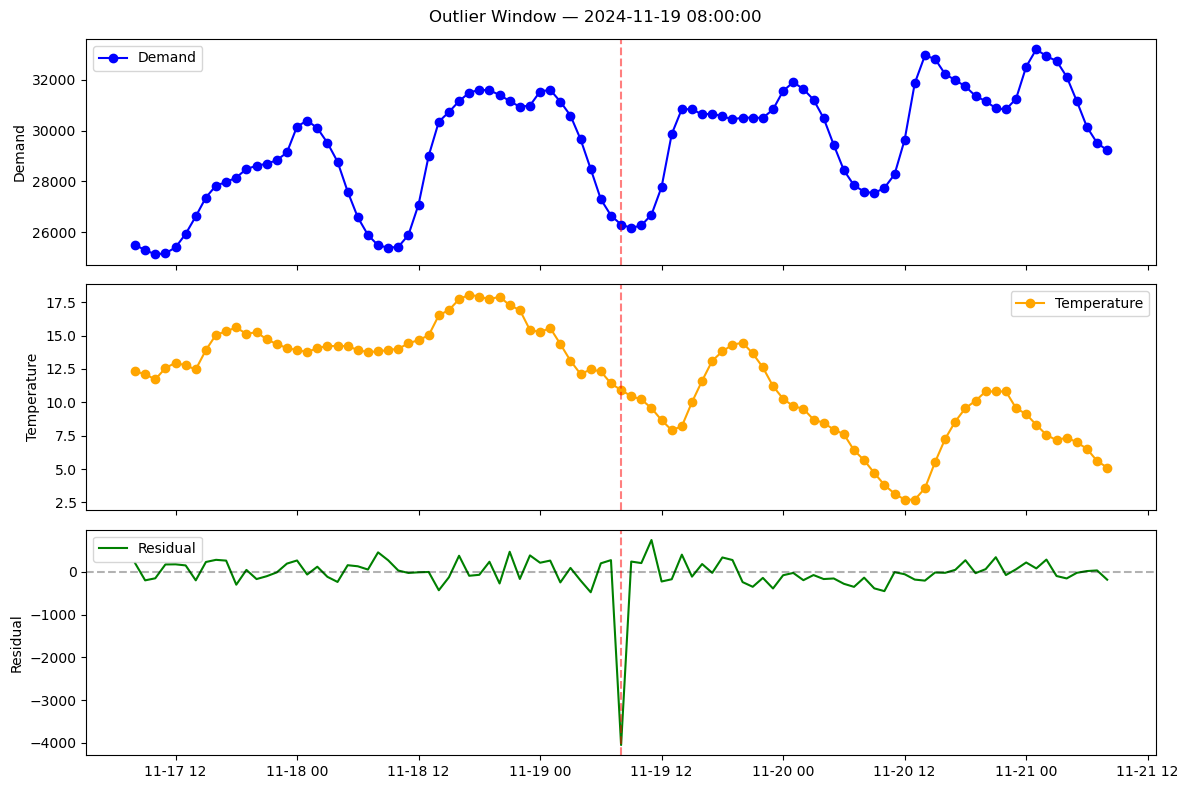

In [44]:
plot_outlier_window(outliers.index[0])

In [45]:
def plot_outlier_exog_window(date, window_hours=48):
    start = date - pd.Timedelta(hours=window_hours)
    end = date + pd.Timedelta(hours=window_hours)

    window_data = data.loc[start:end]
    window_resid = residuals.loc[start:end]

    exog_cols = ['Holiday', 'week', 'day_of_week', 'hour',
                 'week_sin', 'week_cos', 'day_sin', 'hour_sin', 'hour_cos']

    fig, axes = plt.subplots(len(exog_cols) + 1, 1, figsize=(12, 2 * (len(exog_cols) + 1)), sharex=True)

    for i, col in enumerate(exog_cols):
        axes[i].plot(window_data.index, window_data[col], label=col, color="steelblue", marker = "o")
        axes[i].axvline(date, color="red", linestyle="--", alpha=0.5)
        axes[i].set_ylabel(col, fontsize=8)
        axes[i].legend(fontsize=7, loc="upper right")

    axes[-1].plot(window_resid.index, window_resid, label="Residual", color="green")
    axes[-1].axhline(0, color="black", linestyle="--", alpha=0.3)
    axes[-1].axvline(date, color="red", linestyle="--", alpha=0.5)
    axes[-1].set_ylabel("Residual", fontsize=8)
    axes[-1].legend(fontsize=7, loc="upper right")

    plt.suptitle(f"Exogenous Features Around Outlier — {date}")
    plt.tight_layout()
    plt.show()



In [ ]:
# Plot top outlier
plot_outlier_exog_window(outliers.index[0])

In [47]:
# Get the exact features used for this prediction
X_train, y_train = forecaster.create_train_X_y(
    y=data.loc[:VAL_END, 'Demand'],
    exog=data.loc[:VAL_END, exog_select]
)

# Find the row corresponding to your outlier date
outlier_date = outliers.index[0]
print(X_train.loc[outlier_date])

lag_1             26656.0
lag_2             27295.0
lag_3             28486.0
lag_4             29655.0
lag_10            30933.0
lag_20            27089.0
lag_21            25890.0
lag_22            25420.0
lag_23            25389.0
lag_24            25482.0
lag_25            25891.0
lag_26            26584.0
lag_27            27598.0
lag_28            28774.0
lag_167           26002.0
lag_170           27143.0
Temperature       10.9115
Holiday               0.0
week                 47.0
day_of_week           1.0
hour                  8.0
week_sin        -0.568065
week_cos         0.822984
day_sin          0.781831
hour_sin         0.866025
hour_cos             -0.5
Temp_3D_Mean    13.759416
Temp_2D_Max       18.0615
Temp_2D_Min       10.9115
Temp_1D_Max       18.0615
Temp_1D_Min       10.9115
Name: 2024-11-19 08:00:00, dtype: Float64


### Hyper Parameter Tuning

In [163]:
# Hyperparameters search
# ==============================================================================
"""
### Train Val Test Split
TRAIN_START = "2023-01-01 00:00:00"
TRAIN_END   = "2024-06-30 23:00:00"
VAL_START   = "2024-07-01 00:00:00"
VAL_END     = "2024-12-31 23:00:00"
TEST_START  = "2025-01-01 00:00:00"
TEST_END    = "2025-12-31 23:00:00"
"""
tuned_forecaster = ForecasterRecursive(
                 estimator       = LGBMRegressor(random_state=15926, verbose=-1),
                 lags            = lags_select
             )

# Estimator hyperparameters search space
def search_space(trial):
    search_space  = {
        'n_estimators' : trial.suggest_int('n_estimators', 300, 1000, step=100),
        'max_depth'    : trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.5),
        'reg_alpha'    : trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda'   : trial.suggest_float('reg_lambda', 0, 1),
    } 
    return search_space

# Folds training and validation
cv_search = TimeSeriesFold(
                steps              = 24,
                initial_train_size = len(data[:TRAIN_END]),
                refit              = False,
            )

results_search, frozen_trial = bayesian_search_forecaster(
                                   forecaster   = tuned_forecaster,
                                   y            = data.loc[:VAL_END, 'Demand'],
                                   exog         = data.loc[:VAL_END, exog_select],
                                   cv           = cv_search,
                                   metric       = 'mean_absolute_error',
                                   search_space = search_space,
                                   n_trials     = 10,  # Increase for more exhaustive search
                                   return_best  = True
                               )
tuned_forecaster

/Users/maxwellgriffith/miniconda3/envs/loadcast/lib/python3.11/site-packages/optuna/samplers/_tpe/sampler.py:82: FutureWarning: `consider_endpoints` has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  optuna_warn(msg, FutureWarning)
Best trial: 3. Best value: 822.202: 100%|██████████████████████████| 10/10 [00:17<00:00,  1.75s/it]


=================== 
ForecasterRecursive 
=================== 
Estimator: LGBMRegressor 
Lags: [  1   2   3   4  10  20  21  22  23  24  25  26  27  28 167 170] 
Window features: None 
Window size: 170 
Series name: Demand 
Exogenous included: True 
Exogenous names: 
    Temperature, week, day_of_week, hour, week_sin, hour_sin, hour_cos,
    Temp_3D_Mean, Temp_2D_Max, Temp_2D_Min, Temp_1D_Min 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2023-01-01 00:00:00'), Timestamp('2024-12-31 23:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Hour> 
Estimator parameters: 
    {'boosting_type': 'gbdt', 'class_weight': None, 'colsample_bytree': 1.0,
    'importance_type': 'split', 'learning_rate': 0.09597136051227133,
    'max_depth': 4, 'min_child_samples': 20, 'min_child_weight': 0.001,
    'min_split_gain': 0.0, 'n_estimators': 800, 'n_jobs': None, 'num_leaves':
    31, 'objective': None, 'random_state': 15926, 'reg_alpha':
    0.5315513738418384, 'reg_lambda': 0.5318275870968661, 'subsample': 1.0,
    'subsample_for_bin': 200000, 'subsample_freq': 0, 'verbose': -1} 
fit_kwargs: {} 
Creation date: 2026-06-25 11:42:02 
Last fit date: 2026-06-25 11:42:21 
Skforecast version: 0.22.0 
Python version: 3.11.13 
Forecaster id: None

In [164]:
# Backtest final model on test data
# ==============================================================================
metric, predictions = backtesting_forecaster(
                          forecaster = tuned_forecaster,
                          y          = data['Demand'],
                          exog       = data[exog_select],
                          cv         = cv,
                          metric     = 'mean_absolute_error'
                      )
display(metric)
predictions.head()

100%|███████████████████████████████████████████████████████████| 365/365 [00:02<00:00, 180.00it/s]


,mean_absolute_error
0,1063.146827


,fold,pred
2025-01-01 00:00:00,0,33989.824806
2025-01-01 01:00:00,0,34642.194480
2025-01-01 02:00:00,0,34567.177639
2025-01-01 03:00:00,0,34568.160098
2025-01-01 04:00:00,0,34135.667293


-well the error went up so idk what to do about that